# Model Comparison, Evaluation Metrics & Real-Time Profiling
We are now comparing three diverse tree-based ensemble architectures to prove which algorithm is best suited for DoH C2 Detection:
1. **Random Forest (Bagging Ensemble)**
2. **Gradient Boosting (Boosting Ensemble)**
3. **XGBoost (Extreme Gradient Boosting)**

In [30]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Load Synthetic Data & Preprocess

In [31]:
file_path = r'C:\Users\mughe\Desktop\NDP - Model Optimization\labeled_doh_dataset.csv'
df = pd.read_csv(file_path)
drop_cols = ['src_ip', 'dst_ip', 'src_mac', 'dst_mac', 'src_port', 'dst_port', 'timestamp', 'flow_id']
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True, errors='ignore')
df.replace([np.inf, -np.inf, 'Infinity'], np.nan, inplace=True)
df.dropna(inplace=True)

X = df.drop(columns=['Label'])

# XGBoost requires numeric labels, so we encode Benign=0, Malicious=1
y = df['Label'].apply(lambda x: 1 if x == 'Malicious' else 0)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

## 2. Train Random Forest Model
A bagging ensemble that uses many decision trees to build a robust consensus.

In [32]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Ready!")

Training Random Forest...
Random Forest Ready!


## 3. Train Gradient Boosting Model
A boosting ensemble that sequentially corrects the errors of previous trees.

In [33]:
print("Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
print("Gradient Boosting Ready!")

Training Gradient Boosting...
Gradient Boosting Ready!


## 4. Train XGBoost Model
Extreme Gradient Boosting: A highly optimized, parallelized implementation of gradient boosting.

In [34]:
print("Training XGBoost...")
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_model.fit(X_train, y_train)
print("XGBoost Ready!")

Training XGBoost...
XGBoost Ready!


## 5. Combine & Evaluate All Models
Evaluating Precision, Recall, F1-Score, and plotting Confusion Matrices side-by-side.

================ Random Forest ================
Accuracy: 100.00%
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        15
   Malicious       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

================ Gradient Boosting ================
Accuracy: 100.00%
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        15
   Malicious       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

================ XGBoost ================
Accuracy: 100.00%
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        15
   Malicious       1.00      1.00      1.

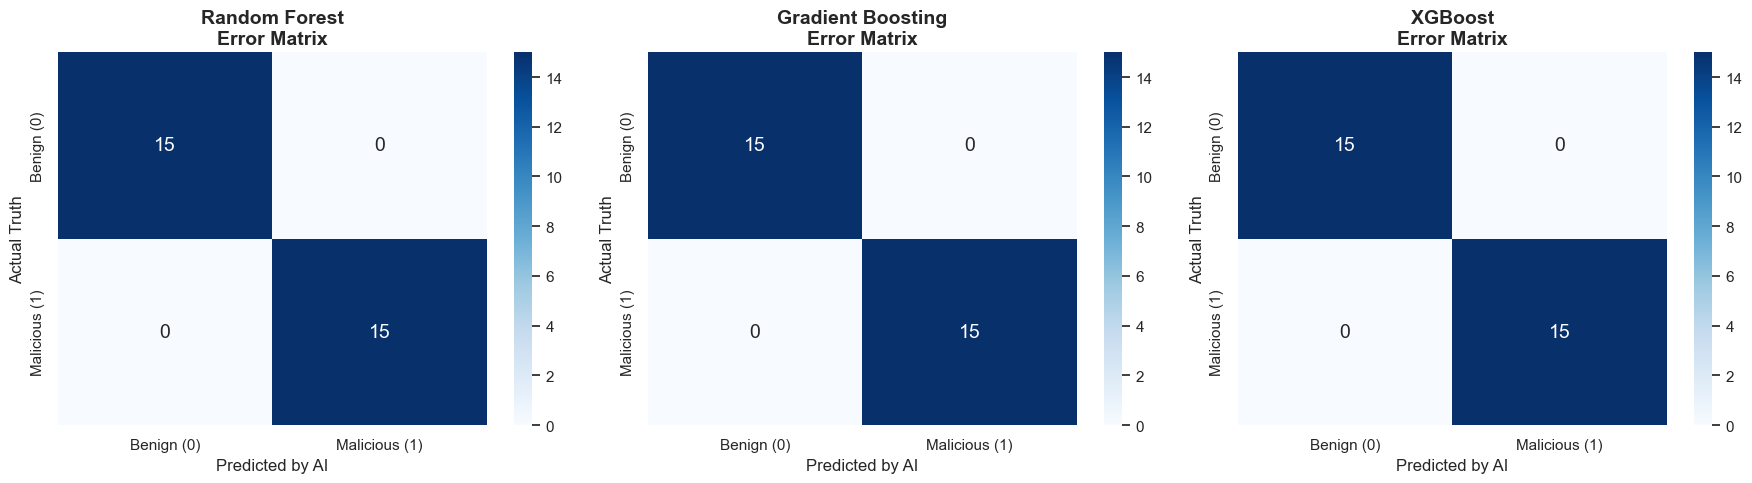

In [35]:
models = {
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model,
    'XGBoost': xgb_model
}
class_names = ['Benign (0)', 'Malicious (1)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    print(f"================ {name} ================")
    print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malicious']))
    
    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14})
    axes[i].set_title(f'{name}\nError Matrix', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted by AI')
    axes[i].set_ylabel('Actual Truth')

plt.tight_layout()
plt.savefig('Confusion_Matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. ROC Curve Comparison
The Receiver Operating Characteristic (ROC) visually demonstrates which model has the best True Positive to False Positive ratio.

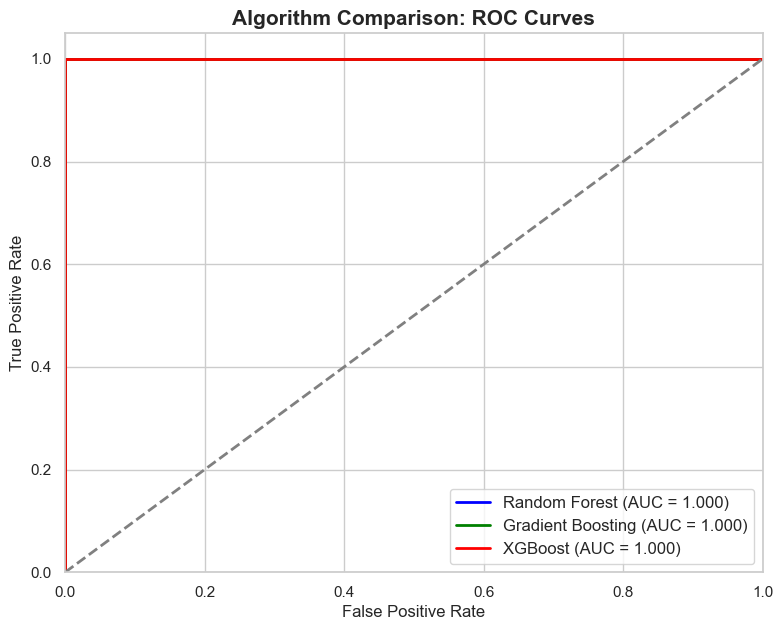

In [36]:
plt.figure(figsize=(9, 7))

colors = ['blue', 'green', 'red']
for color, (name, model) in zip(colors, models.items()):
    y_prob = model.predict_proba(X_test)[:, 1] # Probability of 'Malicious'
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Algorithm Comparison: ROC Curves', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.savefig('ROC_Curve_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Real-Time Detection Profiling (Latency & Throughput)
We simulate a real-time streaming environment to see which architecture is lightweight enough to run on live network gateways.

In [37]:
results = []
X_stream = X_test.to_numpy()

for name, model in models.items():
    latencies = []
    
    for i in range(len(X_stream)):
        single_flow = X_stream[i].reshape(1, -1)
        
        start_time = time.perf_counter()
        _ = model.predict(single_flow)
        end_time = time.perf_counter()
        
        latencies.append((end_time - start_time) * 1000) # milliseconds
        
    avg_lat = np.mean(latencies)
    tp = 1000 / avg_lat if avg_lat > 0 else 0
    results.append({
        'Model': name,
        'Avg Latency (ms)': avg_lat,
        'Throughput (Flows/Sec)': tp
    })

df_stats = pd.DataFrame(results)
print("\n--- Real-Time System Profiling ---")
display(df_stats)


--- Real-Time System Profiling ---


,Model,Avg Latency (ms),Throughput (Flows/Sec)
0,Random Forest,5.165423,193.594975
1,Gradient Boosting,0.133490,7491.199380
2,XGBoost,0.344773,2900.456060


## 8. System Profiling Visualizations
A final chart showing the trade-off between architectural complexity and network speed.

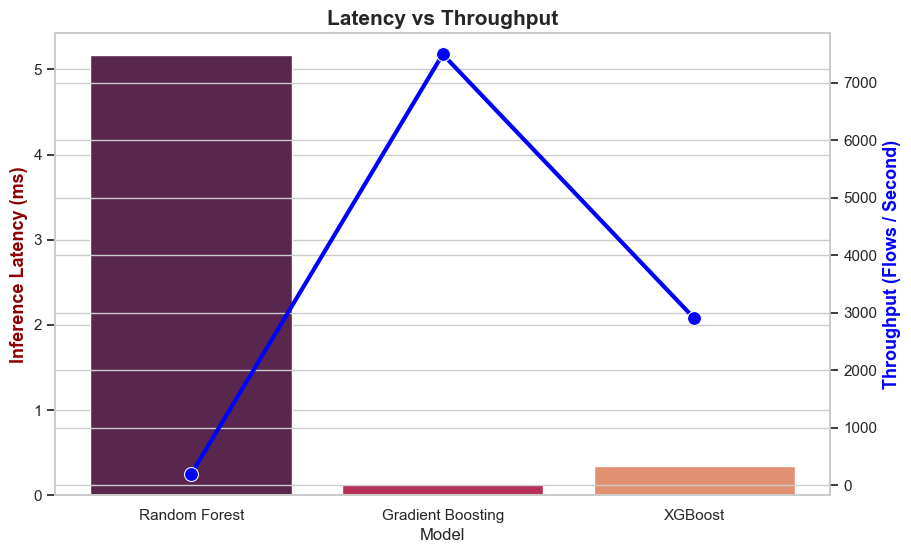

In [38]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Latency
sns.barplot(x='Model', y='Avg Latency (ms)', data=df_stats, ax=ax1, palette='rocket')
ax1.set_ylabel('Inference Latency (ms)', fontsize=13, color='darkred', fontweight='bold')
ax1.set_title('Latency vs Throughput', fontsize=15, fontweight='bold')

# Line plot overlay for Throughput on the secondary axis
ax2 = ax1.twinx() 
sns.lineplot(x='Model', y='Throughput (Flows/Sec)', data=df_stats, ax=ax2, color='blue', marker='o', markersize=10, linewidth=3)
ax2.set_ylabel('Throughput (Flows / Second)', fontsize=13, color='blue', fontweight='bold')

plt.savefig('RealTime_Stats_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()